In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

from IPython import display

In [2]:
from matplotlib import pyplot as plt
import plotly.express as px
import torch
import bindsnet
import os
import numpy as np
import math
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [3]:
from time import time as t

from bindsnet.network import Network
from bindsnet.learning import WeightDependentPostPre
from bindsnet.learning import NoOp
from bindsnet.encoding import bernoulli_loader
from bindsnet.network.monitors import NetworkMonitor
from bindsnet.network.nodes import Input, LIFNodes,IFNodes
from bindsnet.network.topology import Connection

In [4]:

file_out = pd.read_csv("C:/Users/Всеволод/Desktop/наука/heart_failure_clinical_records_dataset.csv")
data_from_file = file_out.values
sc = MinMaxScaler()
class_markers = [[0.,1.],
                [1.,0.]]
x_tensor = data_from_file[:, 0:12]
y_tensor = data_from_file[:, 12:13]
data_sc = sc.fit_transform(x_tensor)
x_tensor = torch.tensor(data_sc, dtype = torch.float32)
y_tensor = torch.tensor(y_tensor, dtype = torch.float32)

def generate_dataset(x_tensor, y_tensor, num = 1, validation = False):
    X = []
    y = []
    
    if validation:
        
        x_tensor = torch.narrow (x_tensor,0,249,50)
        y_tensor = torch.narrow (y_tensor,0,249,50)
        
        for i in range(x_tensor.shape[0]): #dimensions are the same
        
            y.append(y_tensor[i])
            
            for k in range(x_tensor.shape[1]):
                         
                    X.append(x_tensor[i][k])
        
        X = torch.tensor(X).reshape(x_tensor.shape[0], 12)
        y = torch.tensor(y).reshape(y_tensor.shape[0], 1)
        
    else:
        
        x_tensor = torch.narrow (x_tensor,0,0,249)
        y_tensor = torch.narrow (y_tensor,0,0,249)
        
        for k in np.arange(num):
            for i in range(x_tensor.shape[0]): #dimensions are the same
                
                y.append(class_markers[int(y_tensor[i])])
                    
                for j in range(x_tensor.shape[1]):
                         
                    X.append(x_tensor[i][j])
        
        X = torch.tensor(X).reshape(num*x_tensor.shape[0], 12)
        y = torch.tensor(y).reshape(num*y_tensor.shape[0], 2)
    
    return X,y


### Set Parameters

In [5]:
#init_weight_value = 0.6
#weights_init_XY = torch.Tensor([[init_weight_value,  1-init_weight_value],#change
                        #        [ 1-init_weight_value, init_weight_value]
                         #      ])
weights_init_XH = 0.5*torch.ones([12, 2])

weights_init_HY = torch.tensor([[-10., 0.],
                                [ 0.,-10.]])
                               
dt = 1.0

### STDP

learning_rate = 1


# Connections
wmin = 0.001
wmax = 1
weight_decay =  9.0e-6

# Neurons
reset = 0

#### Thresholds
refrac = 60
thresh = 85

# Data encoding
intensity = 18
time = 500



### Create Network

In [6]:
network = Network()
input_layer = Input(n=12, 
                    traces=True, 
                    thresh=thresh,
                    rest = reset,
                    reset=reset,
                    refrac=refrac)

hidden_layer = LIFNodes(n=2, 
                     traces=True, 
                     thresh=thresh,
                     rest = reset,
                     reset=reset,
                     refrac=refrac)

inhibitor_layer = Input(n=2, 
                       traces=True, 
                       thresh=thresh,
                       rest = reset,
                       reset=reset,
                       refrac=refrac)

conn_XH = Connection(input_layer, 
                     hidden_layer, 
                     update_rule=WeightDependentPostPre, 
                     w=weights_init_XH, 
                     nu=[learning_rate, learning_rate], 
                     wmin=wmin, 
                     wmax=wmax,
                     weight_decay=weight_decay
                     )

conn_HY = Connection( 
                     inhibitor_layer,
                     hidden_layer,
                     update_rule=NoOp, 
                     w=weights_init_HY, 
                     nu=[learning_rate, learning_rate], 
                     wmin=-9, 
                     wmax=wmax,
                     weight_decay=0
                     )



network.add_layer(input_layer, name='X')
network.add_layer(hidden_layer, name='H')
network.add_layer(inhibitor_layer, name='Y')

network.add_connection(conn_XH, source='X', target='H')
network.add_connection(conn_HY, source='Y', target='H')

GlobalMonitor = NetworkMonitor(network, state_vars=('v', 's', 'w'))
network.add_monitor(GlobalMonitor, name='Network')

print('GlobalMonitor.state_vars:', GlobalMonitor.state_vars)

GlobalMonitor.state_vars: ('v', 's', 'w')


### Create Custom Dataset

In [7]:
len_dataset = 10
input_data, input_data_2 = generate_dataset(x_tensor, y_tensor,len_dataset)
 

input_data *= intensity
input_data_2 *= 100


### Цикл обучения

KeyboardInterrupt: 

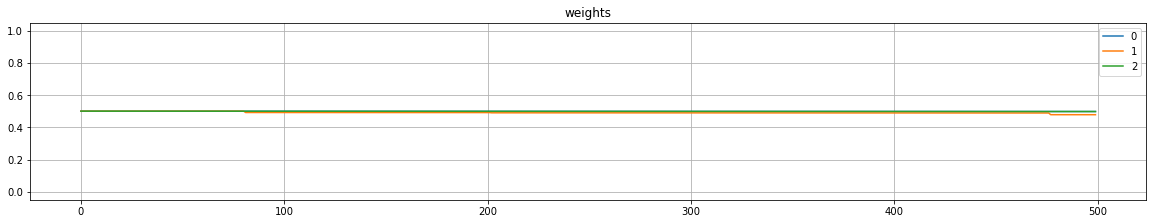

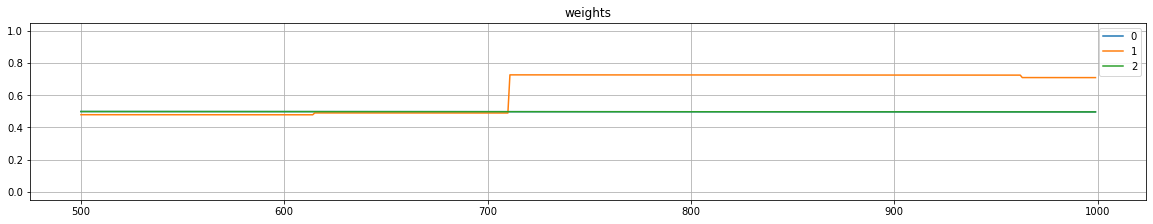

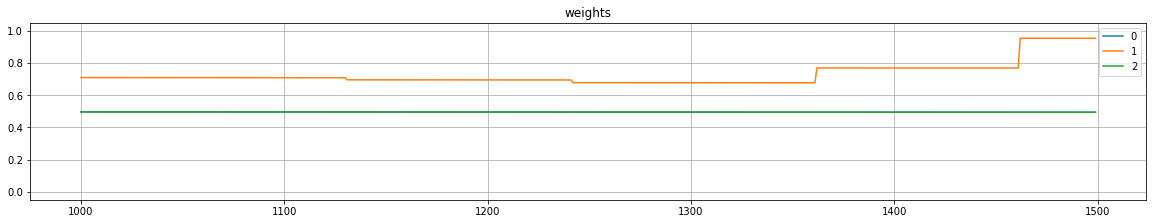

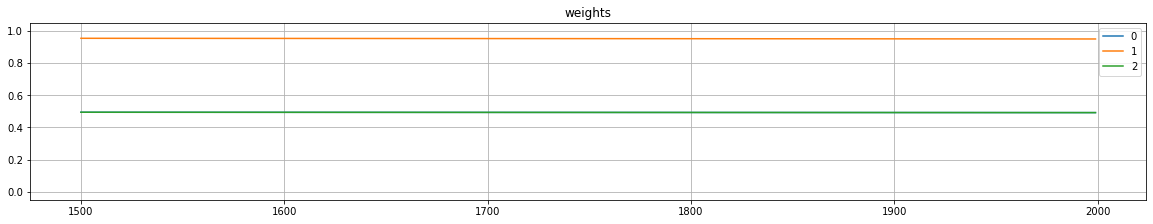

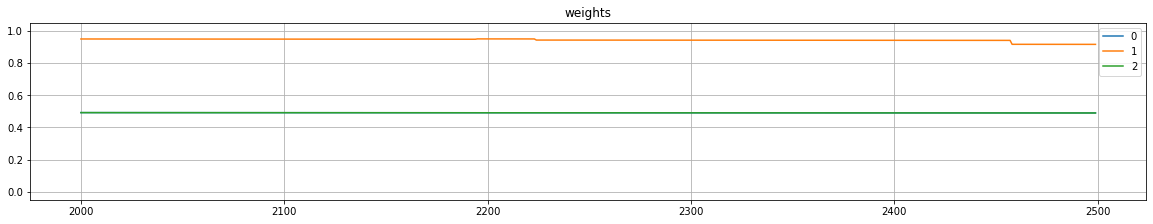

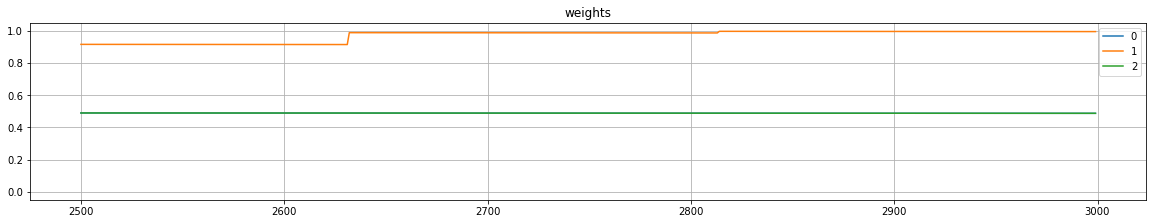

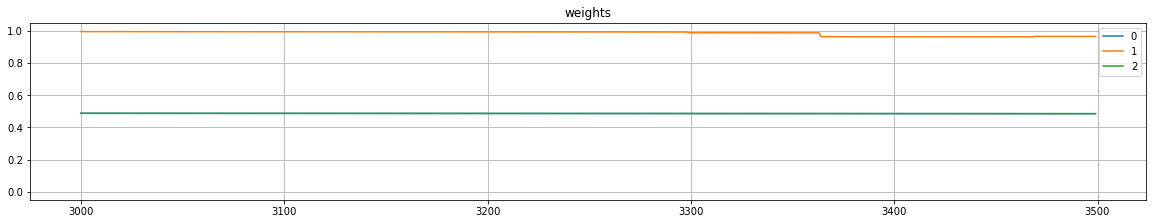

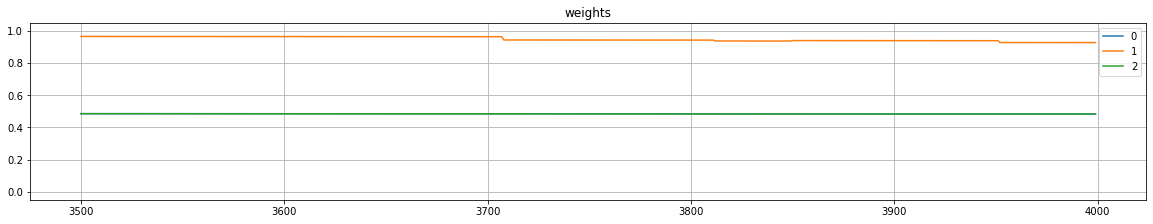

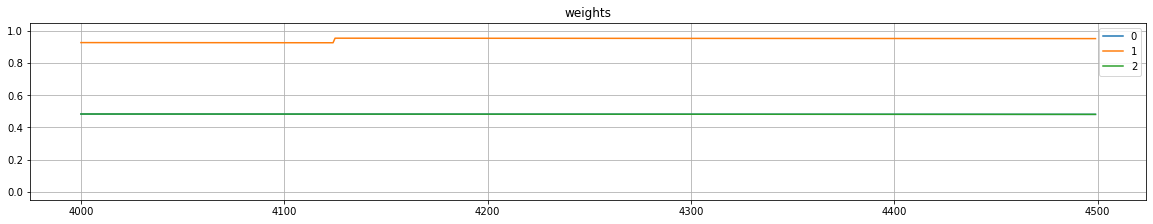

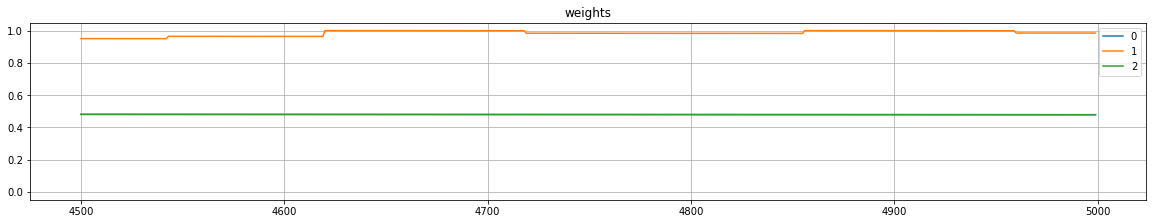

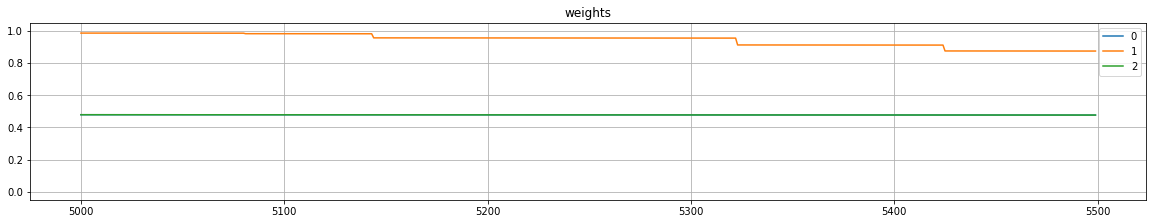

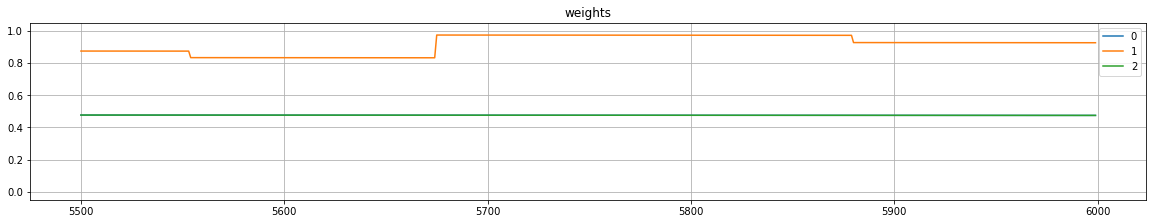

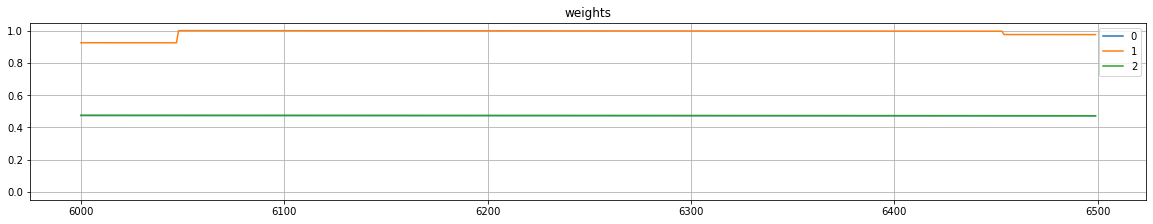

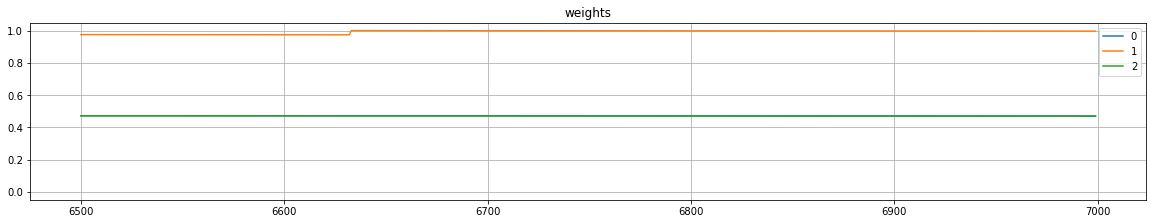

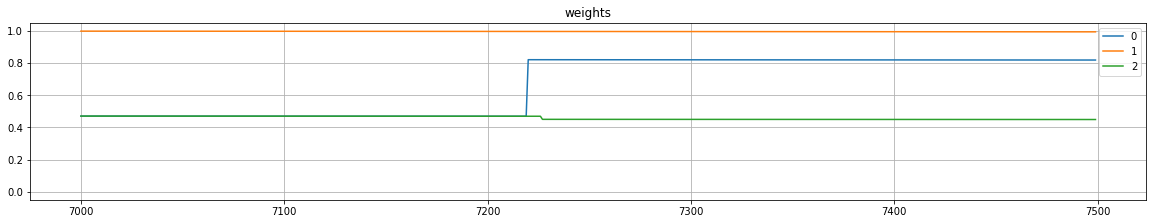

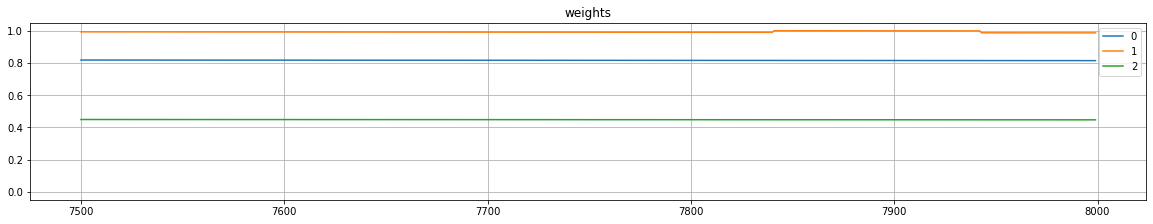

In [8]:
data_loader = bernoulli_loader(data=(input_data/1000)*dt, time=time)
data_loader_2 = bernoulli_loader(data=(input_data_2/1000)*dt, time=time)

print('Begin training.\n');
start = t()
n_train = input_data.shape[0] 
progress_interval = 1 

weights_total = torch.Tensor()
voltages_total = torch.Tensor()


for i in range(n_train):
    #if i % progress_interval == 0:
        #print('Progress: %d / %d (%.4f seconds)' % (i, n_train, t() - start));
        #start = t()

    
    sample = next(data_loader)
    sample_2 = next(data_loader_2)
    
    #print(input_data_2[i])
    
    inpts = {'X': sample, 'Y': sample_2} 

    
    network.run(inpts=inpts, time=time)
    
    
    recordings = network.monitors['Network'].get()
    
    """
    weights = recordings[('H', 'Y')]['w'].view(-1, 20)
    
    voltages = recordings[('Y')]['v']
    """                 
    
    #network.reset_()
    
    fig_w = plt.figure(figsize=(20, 15))
    
    plt.subplot(4,1,1)
    plt.title('weights')
    weights = recordings[('X','H')]['w'].view(-1,24)[:,0:3]
    for j in range(weights.size(1)):
        plt.plot(np.arange(i*weights.size(0), (i+1)*weights.size(0)), weights[:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.ylim(-0.05, 1.05)
    plt.grid()
    """
    
    #Y Voltages
    plt.subplot(1,1,1)
    plt.title('Y voltage')
    voltages = recordings[('H')]['v']
    for j in range(voltages.size(2)):
        plt.plot(np.arange(i*voltages.size(0), (i+1)*voltages.size(0)), voltages[:,:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.hlines([reset, thresh], i*voltages.size(0), (i+1)*voltages.size(0))
    plt.grid()
    """
    display.clear_output(wait=True)
    display.display(fig_w, display_id = 'weights')
    
    
    network.reset_()  # Reset state variables
    
    #plt.close(fig_w)
    

# Validation

In [ ]:
weights_1 = recordings[('X', 'H')]['w'].view(-1, 24)
weights_init_XH_1 = weights_1[-1].view(12, 2) 

network_1 = Network()
input_layer_1 = Input(n=12, 
                    traces=True, 
                    thresh=thresh,
                    rest = reset,
                    reset=reset,
                    refrac=refrac)

hidden_layer_1 = LIFNodes(n=2, 
                     traces=True, 
                     thresh=thresh,
                     rest = reset,
                     reset=reset,
                     refrac=refrac)


conn_XH_1 = Connection(input_layer, 
                     hidden_layer, 
                     update_rule=WeightDependentPostPre, 
                     w=weights_init_XH_1, 
                     nu=[learning_rate, learning_rate], 
                     wmin=wmin, 
                     wmax=wmax,
                     weight_decay=weight_decay
                     )



network_1.add_layer(input_layer_1, name='X_1')
network_1.add_layer(hidden_layer_1, name='H_1')

network_1.add_connection(conn_XH_1, source='X_1', target='H_1')

GlobalMonitor_1 = NetworkMonitor(network_1, state_vars=('v', 's', 'w'))
network_1.add_monitor(GlobalMonitor_1, name='Network_1')

print('GlobalMonitor.state_vars:', GlobalMonitor.state_vars)

In [ ]:
input_data, check_data = generate_dataset(x_tensor, y_tensor, validation = True)
 
input_data *= intensity

data_loader = bernoulli_loader(data=(input_data/1000)*dt, time=time)

n_train = input_data.shape[0] 
progress_interval = 1 

accuracy = 0

for i in range(n_train):
 
    sample = next(data_loader)
    
    inpts = {'X_1': sample} 
    
    network_1.run(inpts=inpts, time=time)
        
    recordings = network_1.monitors['Network_1'].get()
    
    spikes = recordings[('H')]['s'].view(2,-1)
    
    zero = 0
    one = 0
    
    for k in range(spikes.size(1)):
        
        zero += spikes[0][k]
        one += spikes[1][k]
        
    if ((zero > one) and (int(check_data[i])==0)) or ((zero < one) and int(check_data[i])):
        
        accuracy+=1
        
accuracy = accuracy/n_train
print(accuracy)